In [7]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [8]:
def simular_temporada(posiciones_actuales_df, partidos_restantes_df):
    # Inicializar las posiciones finales con las posiciones actuales
    posiciones = {equipo: posicion for equipo, posicion in zip(posiciones_actuales_df['Equipo'], posiciones_actuales_df['Posicion actual'])}
    
    # Simular los partidos restantes y actualizar las posiciones finales
    for _, partido in partidos_restantes_df.iterrows():
        equipo_local = partido['Equipo Local']
        equipo_visitante = partido['Equipo Visitante']
        # Simular el resultado del partido
        resultado = random.choice(['local', 'empate', 'visitante'])
        if resultado == 'local':
            posiciones[equipo_local] += 3
        elif resultado == 'empate':
            posiciones[equipo_local] += 1
            posiciones[equipo_visitante] += 1
        else:
            posiciones[equipo_visitante] += 3
    
    # Ordenar y devolver las posiciones finales
    posiciones_finales = {equipo: 0 for equipo in posiciones_actuales_df['Equipo']}
    for posicion, (equipo, puntos) in enumerate(sorted(posiciones.items(), key=lambda x: x[1], reverse=True), start=1):
        posiciones_finales[equipo] = posicion
    return posiciones_finales

In [9]:
def simular_montecarlo_old(num_simulaciones, posiciones_actuales_df, partidos_restantes_df):
    probabilidad_promedio = {equipo: [0] * (len(posiciones_actuales_df)) for equipo in posiciones_actuales_df['Equipo']}

    for _ in range(num_simulaciones):
        posiciones_finales = simular_temporada(posiciones_actuales_df, partidos_restantes_df)
        for equipo, posicion in posiciones_finales.items():
            probabilidad_promedio[equipo][posicion - 1] += 1

    for equipo, probabilidades in probabilidad_promedio.items():
        total = sum(probabilidades)
        probabilidad_promedio[equipo] = [p / total * 100 for p in probabilidades]

    resultados_df = pd.DataFrame(probabilidad_promedio)
    resultados_df = resultados_df.iloc[::-1]  # Invertir el orden de las filas
    resultados_df.index = range(1, len(resultados_df) + 1)  # Actualizar el índice para comenzar desde 1
    resultados_df.index.name = 'Posicion'
    return resultados_df

In [10]:
def simular_montecarlo(num_simulaciones, posiciones_actuales_df, partidos_restantes_df):
    probabilidad_promedio = {equipo: [0] * (len(posiciones_actuales_df)) for equipo in posiciones_actuales_df['Equipo']}
    
    # Barra de progreso simple que funciona
    for i in tqdm(range(num_simulaciones), desc="Simulaciones Monte Carlo", unit="sim"):
        posiciones_finales = simular_temporada(posiciones_actuales_df, partidos_restantes_df)
        for equipo, posicion in posiciones_finales.items():
            probabilidad_promedio[equipo][posicion - 1] += 1

    # Calcular probabilidades
    for equipo, probabilidades in probabilidad_promedio.items():
        total = sum(probabilidades)
        if total > 0:
            probabilidad_promedio[equipo] = [p / total * 100 for p in probabilidades]

    resultados_df = pd.DataFrame(probabilidad_promedio)
    resultados_df = resultados_df.iloc[::-1]
    resultados_df.index = range(1, len(resultados_df) + 1)
    resultados_df.index.name = 'Posicion'
    return resultados_df

In [11]:
num_simulaciones = 100000

#posiciones_actuales_data = {
#    'Posicion actual': [1, 2, 3, 4],
#    'Equipo': ['América', 'Nacional', 'Millonarios', 'Cali'],
#    'Puntos': [20, 18, 15, 12],
#    'Diferencia de Goles': [10, 8, 6, 4]
#}
#partidos_restantes_data = {
#    'Equipo Local': ['América', 'Nacional', 'Millonarios', 'Cali'],
#    'Equipo Visitante': ['Nacional', 'Millonarios', 'Cali', 'América']
#}

#posiciones_actuales_df = pd.DataFrame(posiciones_actuales_data)
#partidos_restantes_df = pd.DataFrame(partidos_restantes_data)

posiciones_actuales_df = pd.read_csv('Tabla.csv', sep = ';')
partidos_restantes_df = pd.read_csv('Partidos.csv', sep = ';')

resultados_df = simular_montecarlo(num_simulaciones, posiciones_actuales_df, partidos_restantes_df)
#print(resultados_df)

resultados_df.to_excel('Resultados.xlsx')

Simulaciones Monte Carlo: 100%|██████████| 100000/100000 [05:24<00:00, 308.23sim/s]


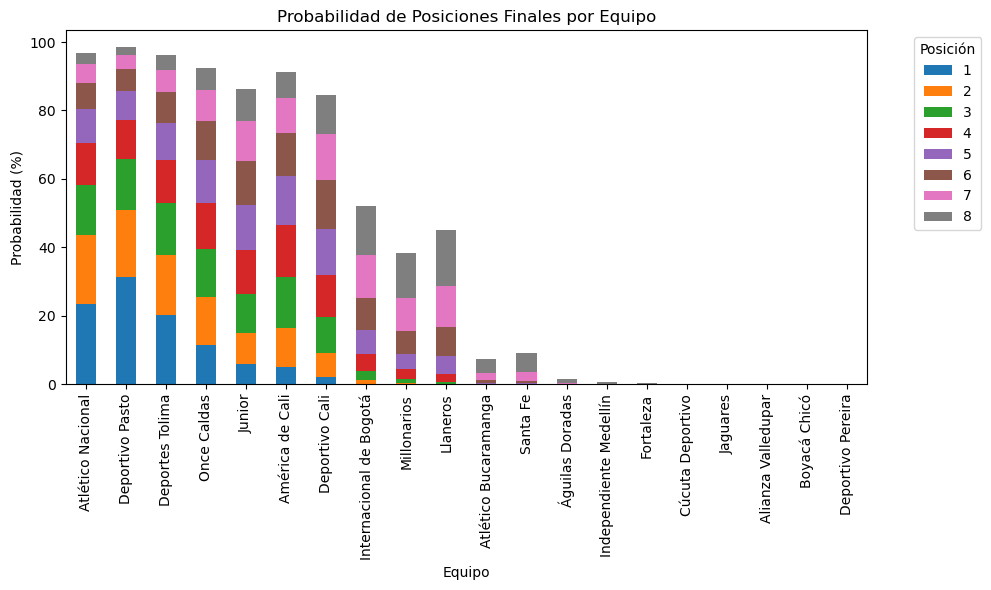

In [12]:
# Graficar el DataFrame como un gráfico de barras apiladas
resultados_df = resultados_df.loc[resultados_df.index <= 8]
ax = resultados_df.T.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Equipo')
plt.ylabel('Probabilidad (%)')
plt.title('Probabilidad de Posiciones Finales por Equipo')
plt.xticks(rotation=90)

# Mostrar los valores de cada zona
#for p in ax.patches:
#    width, height = p.get_width(), p.get_height()
#    x, y = p.get_xy() 
#    ax.annotate(f'{height:.2f}%', (x + width / 2, y + height / 2), ha='center', va='center')

plt.legend(title='Posición', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()